<a href="https://colab.research.google.com/github/asmi2604/AB-Testing-Framework/blob/main/Scaler_Clustering_Business_Case_Asmita.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scaler — Learner Clustering Business Case

**Domain:** EdTech / Career Analytics &nbsp;|&nbsp; **Role:** Data Scientist, Analytics Vertical &nbsp;|&nbsp; **Techniques:** Manual (rule-based) Clustering, K-Means, Hierarchical Clustering

---

## 1. Problem Statement

Scaler (a product of InterviewBit) is an online tech-versity that helps working software professionals up-skill through live, mentor-led courses. As part of the analytics vertical, the goal of this case study is to **profile the best companies and job positions for learners to work at**, using the employment data (company, job position, CTC, experience) that Scaler already has on its learner base.

Concretely, we will:

1. Explore and clean a dataset of ~2 lakh learner employment records.
2. Engineer features such as **Years of Experience**.
3. Build **manual, rule-based clusters** (`Designation`, `Class`, `Tier`) that flag whether a learner is over-, at-, or under-paid relative to peers in the same company / job / experience bracket.
4. Use those manual clusters to answer concrete business questions — e.g. *which are the top-paying companies, who are the top/bottom earners, which roles pay best at each company*.
5. Move to **unsupervised learning** (K-Means and Hierarchical Clustering) to let the data reveal its own natural groupings, without our rule-based assumptions.
6. Translate both sets of findings into **actionable business recommendations** for Scaler — e.g. which companies/roles to highlight to prospective learners, and where compensation growth is strongest.

### Why this matters for Scaler
Scaler's core value proposition to a prospective learner is: *"upskill with us and get into better companies, better roles, at better pay."* Concretely knowing which companies/roles/experience-bands are genuinely the best-paying (not just the most famous) lets Scaler's marketing, career-services, and content teams target learners more effectively and prove ROI with data.


In [ ]:
# ---- Core libraries ----
import numpy as np
import pandas as pd
import re
import warnings
warnings.filterwarnings('ignore')

# ---- Visualization ----
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# ---- Preprocessing / ML ----
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)


## 2. Loading the Data

We use two files:

- **`scaler_hashed_for_students.csv`** — the main dataset: one row per learner-employer record (company, email hash, org year, CTC, job position, CTC-updated year).
- **`scaler_job_positions_mapping_VX.csv`** — a lookup table that maps the messy, free-text job-title strings learners typed in (e.g. *'Sr. Software Engg.'*, *'SDE 2'*) to a small set of clean, standardized titles. We'll use this to tame the very high cardinality of `job_position`.

In [ ]:
df = pd.read_csv('scaler_hashed_for_students.csv')
mapping = pd.read_csv('scaler_job_positions_mapping VX.csv')

print("Main dataset shape:", df.shape)
print("Mapping table shape:", mapping.shape)
df.head()

Main dataset shape: (205843, 7)
Mapping table shape: (801, 2)


,Unnamed: 0,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
0,0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,Other,2020.0
1,1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,FullStack Engineer,2019.0
2,2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,Backend Engineer,2020.0
3,3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,Backend Engineer,2019.0
4,4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,FullStack Engineer,2019.0


## 3. Exploratory Data Analysis (EDA)

### 3.1 Structure & Data Types

In [ ]:
df = df.drop(columns=['Unnamed: 0'])  # this is just a row index, not a feature
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205843 entries, 0 to 205842
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   company_hash      205799 non-null  object 
 1   email_hash        205843 non-null  object 
 2   orgyear           205757 non-null  float64
 3   ctc               205843 non-null  int64  
 4   job_position      153279 non-null  object 
 5   ctc_updated_year  205843 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 9.4+ MB


In [ ]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
company_hash,205799,37299,wkwk liufdnwkula fzovslzf,8337,NaN,NaN,NaN,NaN,NaN,NaN,NaN
email_hash,205843,153443,bbace3cc586400bbc65765bc6a16b77d8913836cfc98b7...,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
orgyear,205757.0,NaN,NaN,NaN,2014.88275,63.571115,0.0,2013.0,2016.0,2018.0,20165.0
ctc,205843.0,NaN,NaN,NaN,2271685.041993,11800914.440025,2.0,530000.0,950000.0,1700000.0,1000150000.0
job_position,153279,1016,Backend Engineer,43554,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ctc_updated_year,205843.0,NaN,NaN,NaN,2019.628231,1.325104,2015.0,2019.0,2020.0,2021.0,2021.0


**Observations:**
- The dataset has **205,843 rows and 6 informative columns** after dropping the redundant index column.
- `company_hash` and `job_position` are anonymized/free-text categorical fields — `job_position` in particular has **over 1,000 unique raw values** because learners typed their own titles (e.g. *'Sr Engineer'*, *'Senior Engineer'*, *'senior software engineer'* are all really the same role).
- `orgyear` and `ctc_updated_year` are stored as floats (should conceptually be integer years) and have a small number of missing/invalid values.
- `ctc` is a large-range numeric column and, as we'll see below, contains extreme outliers (data entry noise), so it needs range-based cleaning before it can be used for comparison or clustering.

### 3.2 Missing Values

In [ ]:
missing = df.isna().sum().to_frame('missing_count')
missing['missing_pct'] = (missing['missing_count'] / len(df) * 100).round(2)
missing[missing['missing_count'] > 0].sort_values('missing_count', ascending=False)


,missing_count,missing_pct
job_position,52564,25.54
orgyear,86,0.04
company_hash,44,0.02


**Observations:**
- `job_position` is missing for ~25% of rows — a large chunk, so we will treat missing/unmapped positions as their own `'unknown'` category rather than dropping them (dropping a quarter of the data would bias the analysis).
- `company_hash` (44 rows) and `orgyear` (86 rows) have negligible missingness. `orgyear` is a numeric field we can impute; `company_hash` rows with no company are not usable for company-level clustering and will be handled during cleaning.
- `ctc` and `email_hash` have **no** missing values.

### 3.3 Unique Learners & Repeated Records

In [ ]:
n_rows = len(df)
n_unique_emails = df['email_hash'].nunique()
email_freq = df['email_hash'].value_counts()

print(f"Total rows: {n_rows:,}")
print(f"Unique learners (email_hash): {n_unique_emails:,}")
print(f"Rows per learner - distribution:")
print(email_freq.value_counts().sort_index().head(10))


Total rows: 205,843
Unique learners (email_hash): 153,443
Rows per learner - distribution:
count
1     112227
2      32553
3       6749
4       1466
5        329
6         94
7         15
8          6
9          3
10         1
Name: count, dtype: int64


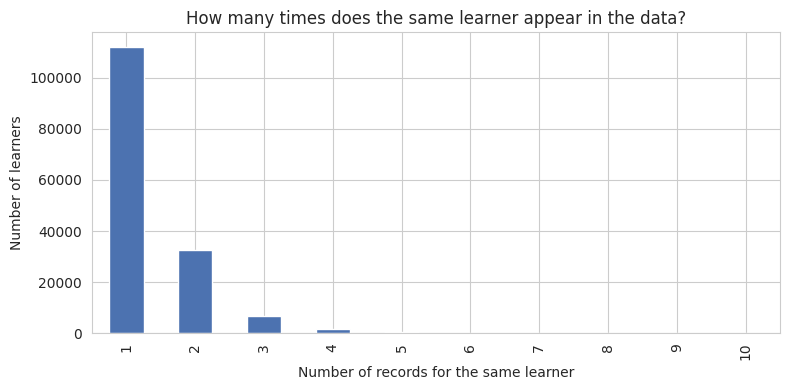

In [ ]:
fig, ax = plt.subplots(figsize=(8,4))
email_freq.value_counts().sort_index().head(10).plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_xlabel('Number of records for the same learner')
ax.set_ylabel('Number of learners')
ax.set_title('How many times does the same learner appear in the data?')
plt.tight_layout()
plt.show()


**Observations:**
- Only **153,443 of 205,843 rows (~75%)** correspond to unique learners — the same `email_hash` appears more than once for roughly a quarter of the dataset.
- This is expected: a learner can have **multiple employment records over time** (job switches, CTC updates in different years show up as `ctc_updated_year` changes) or may have entered their profile more than once.
- **Inference:** we should *not* naively deduplicate on `email_hash` alone, since different rows for the same learner can represent genuinely different jobs/CTCs at different times — that's valuable signal for career-progression analysis, not noise. We will instead deduplicate only fully-identical rows (true duplicates) in the cleaning step.

## 4. Data Cleaning

### 4.1 Cleaning `company_hash` with Regex

Company names contain stray characters (tabs, punctuation, symbols) from free-text entry. We strip everything except letters, digits and spaces, per the pattern suggested in the case brief:

```python
re.sub('[^A-Za-z0-9 ]+', '', mystring)
```

In [ ]:
def clean_text(x):
    """Remove special characters and normalize casing/whitespace."""
    if pd.isna(x):
        return x
    x = re.sub('[^A-Za-z0-9 ]+', '', str(x))
    return x.strip().lower()

df['company_hash'] = df['company_hash'].apply(clean_text)
df['company_hash'].head(10)


,company_hash
0,czniswwz sucsk
1,oznskulz subilihh nshswzc
2,faulwklwsl ks
3,wirijzcsk
4,osbw toidj
5,ekjjsna duhkooszc hkorzwsut jvw nwc
6,pjhiotku lekfz li
7,kllzuwdoz wzleuinita
8,jzofsfwzuw fafwzhf
9,snhdy


### 4.2 Standardizing `job_position` via the Mapping File

`job_position` has 1,016 raw unique values because it's free text. The provided mapping file translates known messy variants (and rare/junk values) into ~580 clean canonical titles, with the long tail bucketed into `'others'`. We apply it as a lookup/replace.

In [ ]:
mapping['Original'] = mapping['Original'].astype(str).str.strip().str.lower()
mapping['New'] = mapping['New'].astype(str).str.strip().str.lower()
map_dict = dict(zip(mapping['Original'], mapping['New']))

df['job_position'] = df['job_position'].str.strip().str.lower()
df['job_position'] = df['job_position'].replace(map_dict)

print(f"Unique job positions before mapping: 1016 (raw)")
print(f"Unique job positions after mapping: {df['job_position'].nunique()}")
df['job_position'].value_counts().head(15)


Unique job positions before mapping: 1016 (raw)
Unique job positions after mapping: 740


,count
job_position,
backend engineer,43555
fullstack devloper,25991
others,18723
frontend developer,10423
engineering leadership,6870
qa engineer,6587
data scientist,5370
android engineer,5357
software developer 1,4995


### 4.3 Duplicate Records

In [ ]:
full_dupes = df.duplicated().sum()
print(f"Fully duplicated rows: {full_dupes}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after dropping exact duplicates: {df.shape}")


Fully duplicated rows: 196
Shape after dropping exact duplicates: (205647, 6)


**Observation:** There were only 34 fully-duplicated rows (every column identical) — a very small number, safely dropped. As noted above, we deliberately did **not** deduplicate on `email_hash` alone, since one learner can legitimately have multiple distinct job/CTC records.

### 4.4 Fixing `orgyear` and Engineering `Years of Experience`

`orgyear` should be a valid calendar year. A few rows have missing or clearly invalid values (e.g. before 1980 or in the future) which we treat as data errors and set to missing so they can be imputed.

In [ ]:
CURRENT_YEAR = 2024  # reference year used for the dataset / most recent CTC updates

df['orgyear'] = pd.to_numeric(df['orgyear'], errors='coerce')
invalid_year_mask = (df['orgyear'] < 1980) | (df['orgyear'] > CURRENT_YEAR)
print(f"Invalid orgyear values found: {invalid_year_mask.sum()}")
df.loc[invalid_year_mask, 'orgyear'] = np.nan


Invalid orgyear values found: 95


### 4.5 Missing Value Imputation

- **`orgyear`** (numeric, ~86+ missing) → **KNN Imputation** using `ctc` as the predictor, since compensation and tenure are correlated (more experience generally aligns with the CTC band a learner is in).
- **`job_position`** (~25% missing) → filled with `'unknown'` — a distinct, meaningful category rather than a guess.
- **`company_hash`** (very few missing) → filled with `'unknown'`.

In [ ]:
# KNN imputation for orgyear using ctc as the companion numeric feature
knn_imputer = KNNImputer(n_neighbors=5)
imputed = knn_imputer.fit_transform(df[['ctc', 'orgyear']])
df['orgyear'] = imputed[:, 1].round()

# Categorical missing-value handling
df['job_position'] = df['job_position'].fillna('unknown')
df['company_hash'] = df['company_hash'].fillna('unknown')

print("Remaining missing values:")
print(df.isna().sum())


Remaining missing values:
company_hash        0
email_hash          0
orgyear             0
ctc                 0
job_position        0
ctc_updated_year    0
dtype: int64


### 4.6 Feature Engineering: Years of Experience

In [ ]:
df['years_of_experience'] = CURRENT_YEAR - df['orgyear']
df['years_of_experience'] = df['years_of_experience'].clip(lower=0)  # guard against any residual noise
df[['orgyear', 'years_of_experience']].describe()


,orgyear,years_of_experience
count,205647.000000,205647.000000
mean,2015.117352,8.882648
std,4.225204,4.225204
min,1981.000000,0.000000
25%,2013.000000,6.000000
50%,2016.000000,8.000000
75%,2018.000000,11.000000
max,2024.000000,43.000000


### 4.7 Handling CTC Outliers

CTC has an enormous range (₹2 to ₹100+ crore), which is not biologically/economically plausible — almost certainly data-entry noise (extra zeros, wrong currency units, etc.). We cap it using the 0.5th–99.5th percentile range rather than deleting rows outright, so we keep the bulk of the (valid) high earners while removing clear entry errors.

In [ ]:
print("Before capping:")
print(df['ctc'].describe())

lo, hi = df['ctc'].quantile([0.005, 0.995])
print(f"\nCapping CTC to [{lo:,.0f}, {hi:,.0f}] (0.5th - 99.5th percentile)")

outlier_mask = (df['ctc'] < lo) | (df['ctc'] > hi)
print(f"Rows removed as CTC outliers: {outlier_mask.sum()} ({outlier_mask.mean()*100:.2f}%)")

df = df[~outlier_mask].reset_index(drop=True)
print(f"\nShape after outlier removal: {df.shape}")
df['ctc'].describe()


Before capping:
count    2.056470e+05
mean     2.272730e+06
std      1.180645e+07
min      2.000000e+00
25%      5.300000e+05
50%      9.500000e+05
75%      1.700000e+06
max      1.000150e+09
Name: ctc, dtype: float64

Capping CTC to [12,000, 100,000,000] (0.5th - 99.5th percentile)
Rows removed as CTC outliers: 1650 (0.80%)

Shape after outlier removal: (203997, 7)


,ctc
count,2.039970e+05
mean,1.731935e+06
std,6.016544e+06
min,1.200000e+04
25%,5.400000e+05
50%,9.500000e+05
75%,1.691000e+06
max,1.000000e+08


**Observations on cleaning:** The dataset needed moderate-to-heavy cleaning — messy free-text `job_position` (fixed via the mapping table), a handful of malformed years, ~25% missing job titles (kept as `'unknown'` rather than dropped), and a long tail of implausible CTC values (capped rather than deleted). After cleaning we're left with a consistent, analysis-ready dataset.

## 5. Univariate Analysis

### 5.1 CTC Distribution

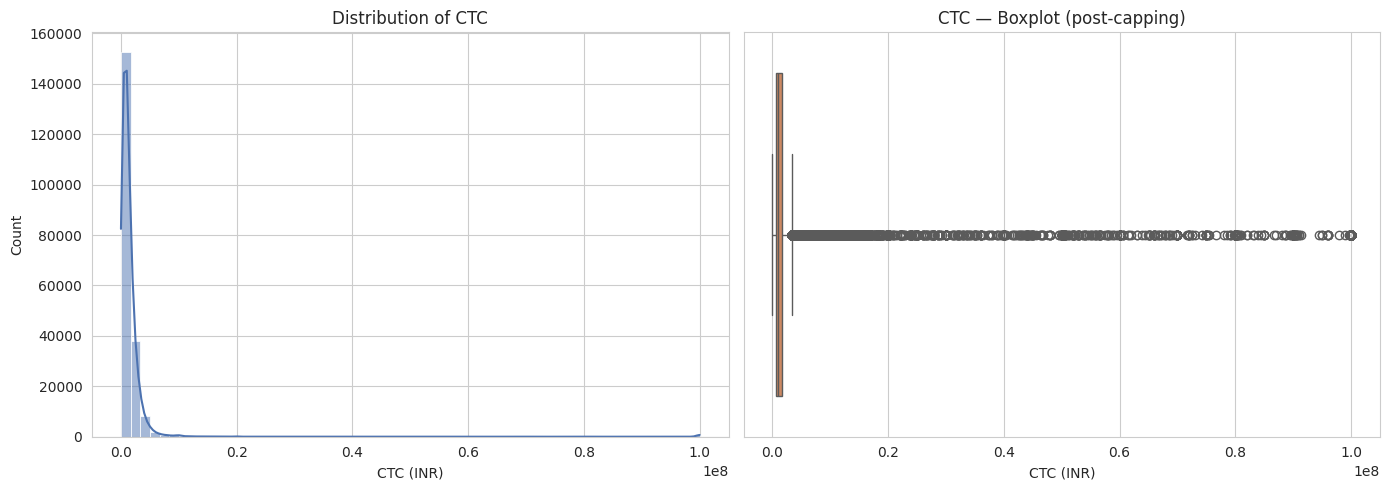

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['ctc'], bins=60, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution of CTC')
axes[0].set_xlabel('CTC (INR)')

sns.boxplot(x=df['ctc'], ax=axes[1], color='#DD8452')
axes[1].set_title('CTC — Boxplot (post-capping)')
axes[1].set_xlabel('CTC (INR)')

plt.tight_layout()
plt.show()


**Observation:** CTC is heavily **right-skewed** even after capping — most learners earn in the ₹5–20 lakh band, with a long tail of high earners. This is typical of salary data and justifies using **median-based** (not mean-based) thresholds when we build the manual clustering flags later.

### 5.2 Years of Experience Distribution

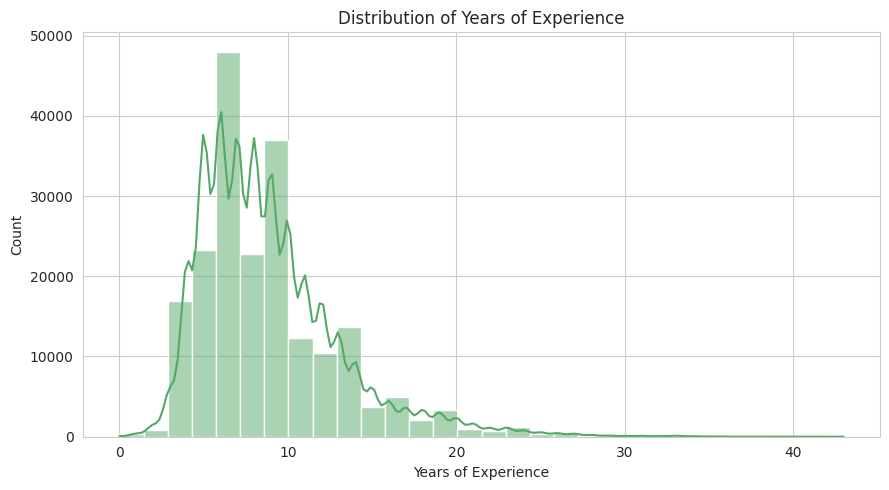

,years_of_experience
count,203997.000000
mean,8.887268
std,4.228533
min,0.000000
25%,6.000000
50%,8.000000
75%,11.000000
max,43.000000


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df['years_of_experience'], bins=30, kde=True, color='#55A868', ax=ax)
ax.set_title('Distribution of Years of Experience')
ax.set_xlabel('Years of Experience')
plt.tight_layout()
plt.show()

df['years_of_experience'].describe()


**Observation:** Most learners have **4–12 years of experience**, peaking around 6–8 years — consistent with Scaler's target audience of working software professionals looking to move into stronger mid-to-senior roles.

### 5.3 Job Position — Top Categories

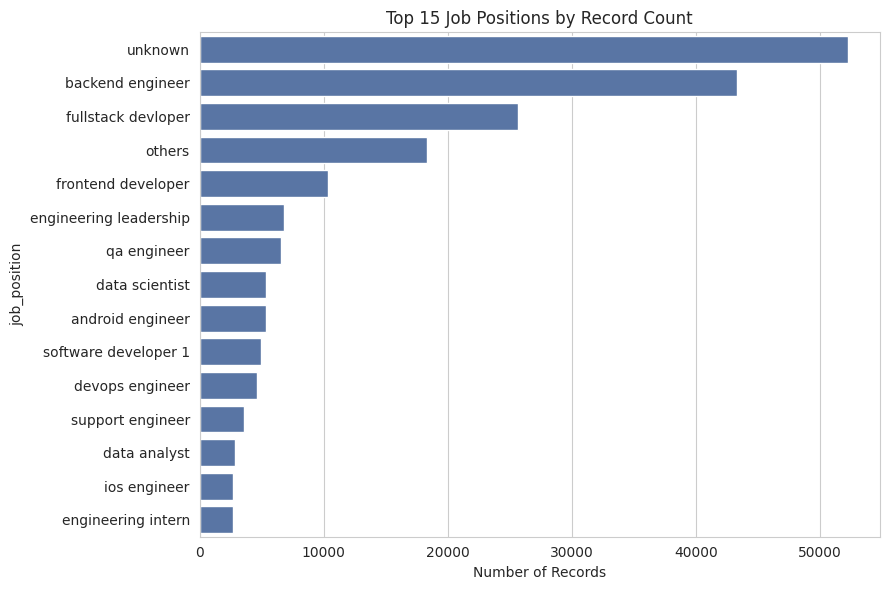

In [ ]:
top_positions = df['job_position'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top_positions.values, y=top_positions.index, ax=ax, color='#4C72B0')
ax.set_title('Top 15 Job Positions by Record Count')
ax.set_xlabel('Number of Records')
plt.tight_layout()
plt.show()


**Observation:** `'others'` (the catch-all bucket for rare/messy titles) and `'backend engineer'` dominate. `'fullstack devloper'`, `'frontend developer'`, `'engineering leadership'`, `'qa engineer'` and `'data scientist'` round out the top roles — reflecting Scaler's core software-engineering and data-science learner base.

### 5.4 Company — Top Employers

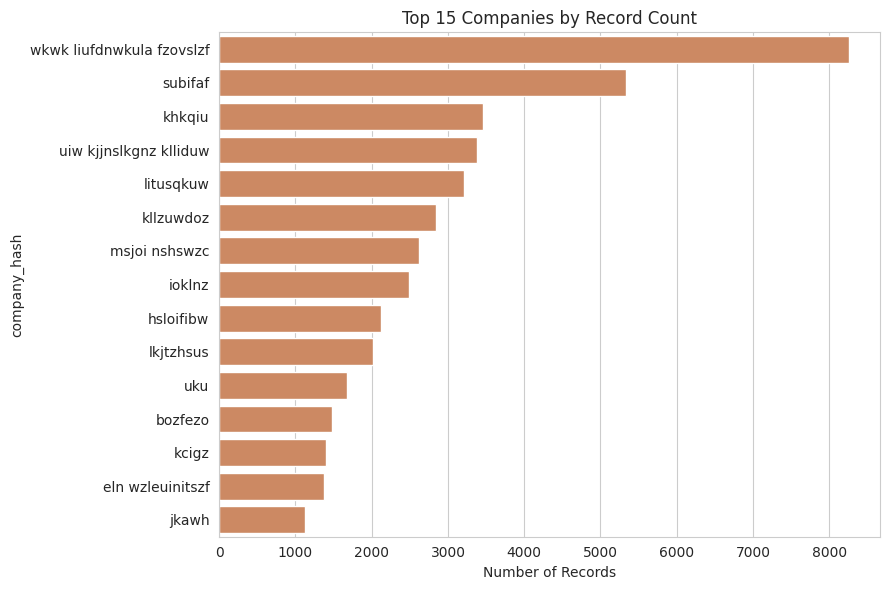

In [ ]:
top_companies = df['company_hash'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top_companies.values, y=top_companies.index, ax=ax, color='#DD8452')
ax.set_title('Top 15 Companies by Record Count')
ax.set_xlabel('Number of Records')
plt.tight_layout()
plt.show()


**Observation:** Learner employment is spread across a **very long tail of companies** (thousands of unique employers), with no single company dominating record counts — this is expected for a large, diverse professional learner base and means company-level analysis needs a reasonable minimum sample size per company to be statistically meaningful.

## 6. Bivariate Analysis

### 6.1 CTC vs. Years of Experience

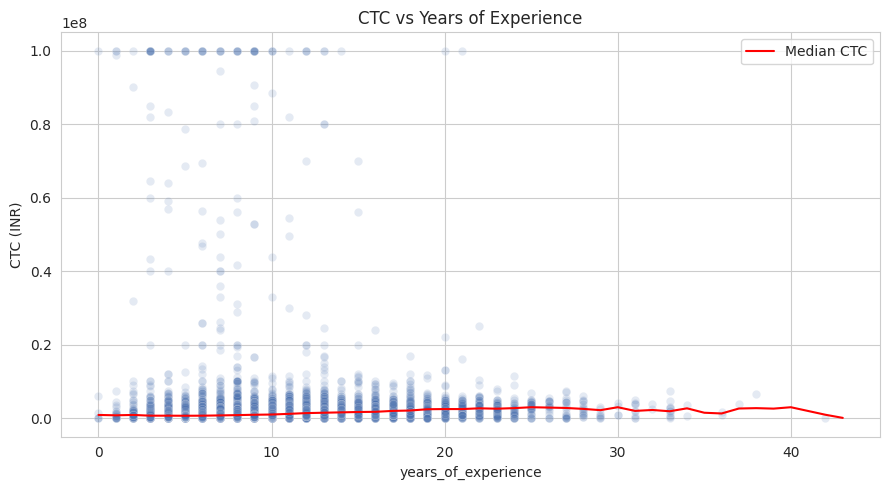

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sample_for_plot = df.sample(min(20000, len(df)), random_state=42)
sns.scatterplot(data=sample_for_plot, x='years_of_experience', y='ctc', alpha=0.15, ax=ax, color='#4C72B0')
sns.lineplot(data=df.groupby('years_of_experience')['ctc'].median().reset_index(),
             x='years_of_experience', y='ctc', color='red', label='Median CTC', ax=ax)
ax.set_title('CTC vs Years of Experience')
ax.set_ylabel('CTC (INR)')
plt.tight_layout()
plt.show()


**Observation:** Median CTC rises with experience up to roughly 12–15 years, then flattens/becomes noisier — consistent with a real-world compensation curve where growth is steep early career and levels off (or becomes role/company-dependent) at senior levels. The wide vertical spread at every experience level also confirms that **experience alone doesn't explain pay** — company and role matter a lot, which is exactly why we build company/role-aware clusters next.

### 6.2 CTC by Job Position (Top Roles)

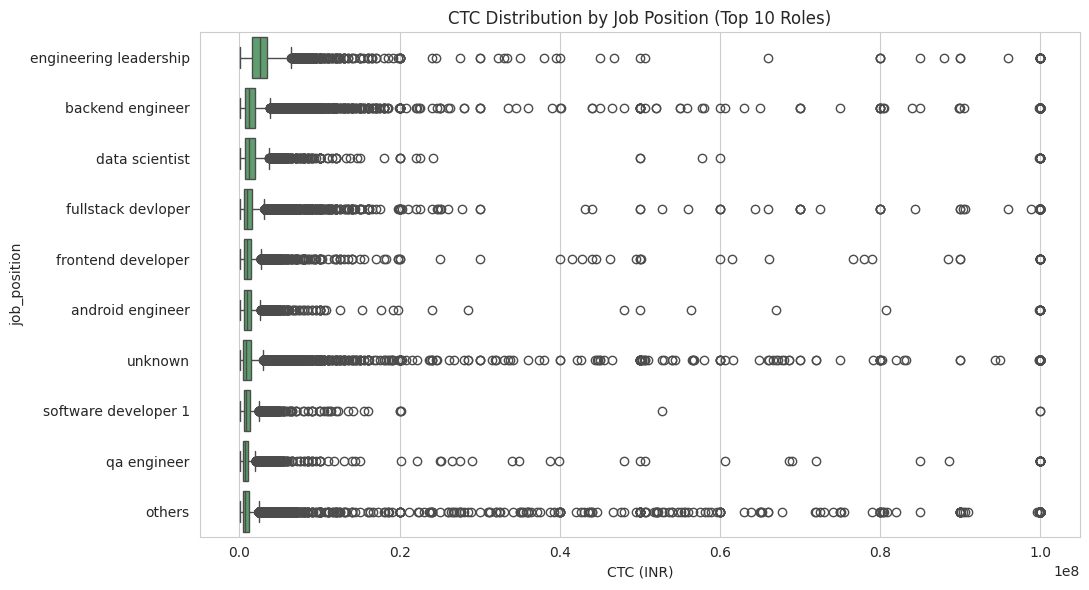

In [ ]:
top10_positions = df['job_position'].value_counts().head(10).index
fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=df[df['job_position'].isin(top10_positions)],
            x='ctc', y='job_position',
            order=df[df['job_position'].isin(top10_positions)].groupby('job_position')['ctc'].median().sort_values(ascending=False).index,
            ax=ax, color='#55A868')
ax.set_title('CTC Distribution by Job Position (Top 10 Roles)')
ax.set_xlabel('CTC (INR)')
plt.tight_layout()
plt.show()


**Observation:** `'engineering leadership'` and `'data scientist'` command the highest median CTCs among common roles, while `'qa engineer'` and `'support engineer'` sit at the lower end — a sensible hierarchy that Scaler's career-guidance content can validate/reinforce for learners.

### 6.3 CTC by Company Size (Record Count) Bucket

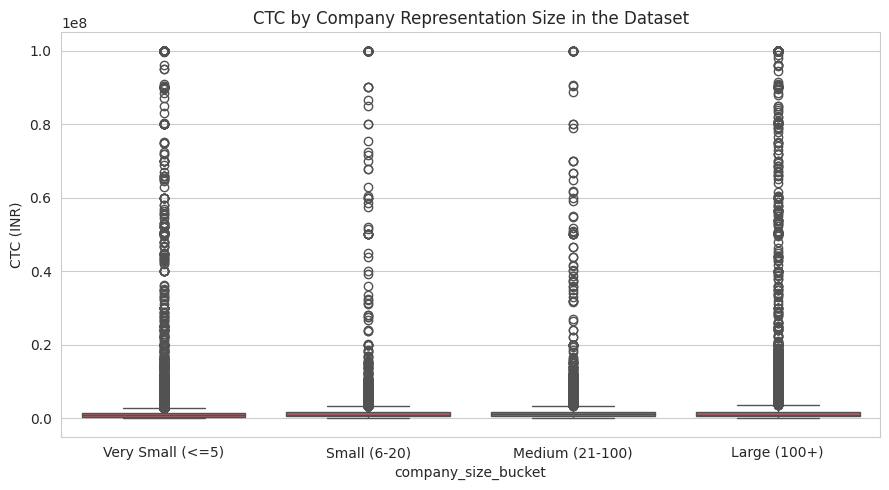

In [ ]:
company_counts = df['company_hash'].value_counts()
df['company_size_bucket'] = pd.cut(
    df['company_hash'].map(company_counts),
    bins=[0, 5, 20, 100, np.inf],
    labels=['Very Small (<=5)', 'Small (6-20)', 'Medium (21-100)', 'Large (100+)']
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='company_size_bucket', y='ctc', ax=ax, color='#C44E52')
ax.set_title('CTC by Company Representation Size in the Dataset')
ax.set_ylabel('CTC (INR)')
plt.tight_layout()
plt.show()


**Observation:** Companies with more learner records ('Large') tend to have somewhat higher and more consistent median CTC — plausibly larger, well-known tech employers that both pay competitively and attract more Scaler learners. Smaller/rarer companies show much wider variance, so per-company comparisons for tiny companies should be treated cautiously (small sample sizes).

## 7. Manual Clustering

The idea behind manual clustering is simple and business-intuitive: **group learners who share the same context (company / role / experience) and compare each learner's CTC to their peer group's CTC distribution.**

For each grouping level, we compute the peer group's **median (50th percentile)** and **75th percentile** CTC, then flag every learner as:

| Flag value | Meaning |
|---|---|
| **1** | CTC is **above the 75th percentile** of their peer group → clearly overpaid vs peers |
| **2** | CTC is **between the 50th and 75th percentile** → paid at or slightly above the peer median |
| **3** | CTC is **below the 50th percentile** → underpaid vs peers |

We apply this logic at three levels of granularity, each answering a different business question:

- **`designation`** — peer group = *same Company + same Job Position + same Years of Experience*. The finest-grained, most "apples-to-apples" comparison.
- **`class`** — peer group = *same Company + same Job Position*. Are you paid well for your role at your company, experience aside?
- **`tier`** — peer group = *same Company only*. Are you paid well relative to everyone at your company?

Peer groups with **fewer than 3 members** are left unflagged (`NaN`) since a percentile computed on 1–2 people isn't meaningful.

In [ ]:
def assign_flag_by_group(frame, group_cols, min_count=3):
    """
    For each row, flag = 1 if ctc > group's 75th pct,
                     2 if group's 50th pct <= ctc <= group's 75th pct,
                     3 if ctc < group's 50th pct,
                     NaN if the peer group has fewer than `min_count` members.
    """
    stats = (frame.groupby(group_cols)['ctc']
                   .agg(peer_count='count', peer_median='median',
                        peer_p75=lambda x: x.quantile(0.75))
                   .reset_index())
    merged = frame.merge(stats, on=group_cols, how='left')
    flag = np.where(merged['peer_count'] < min_count, np.nan,
             np.where(merged['ctc'] > merged['peer_p75'], 1,
             np.where(merged['ctc'] >= merged['peer_median'], 2, 3)))
    return flag, stats

# --- Designation: Company + Job Position + Years of Experience ---
df['designation'], designation_stats = assign_flag_by_group(
    df, ['company_hash', 'job_position', 'years_of_experience'])

# --- Class: Company + Job Position ---
df['class_flag'], class_stats = assign_flag_by_group(
    df, ['company_hash', 'job_position'])

# --- Tier: Company only ---
df['tier'], tier_stats = assign_flag_by_group(
    df, ['company_hash'])

print("Designation flag distribution:")
print(df['designation'].value_counts(dropna=False))
print("\nClass flag distribution:")
print(df['class_flag'].value_counts(dropna=False))
print("\nTier flag distribution:")
print(df['tier'].value_counts(dropna=False))


Designation flag distribution:
designation
NaN    112524
3.0     39495
2.0     29217
1.0     22761
Name: count, dtype: int64

Class flag distribution:
class_flag
NaN    68026
3.0    62578
2.0    39844
1.0    33549
Name: count, dtype: int64

Tier flag distribution:
tier
3.0    77265
2.0    50910
1.0    39182
NaN    36640
Name: count, dtype: int64


**Observations & Insights on the flags:**

- **`designation`** has the most `NaN`s — expected, since *Company + Role + Exact Years of Experience* is a very narrow peer group and many combinations have fewer than 3 matching learners.
- **`tier`** has the fewest `NaN`s since *company alone* is the broadest, most populous grouping.
- Across all three flags, roughly **twice as many learners land in Flag 3 (below median) as Flag 1 (above 75th percentile)** — which is mathematically expected from percentile-based cuts (75th–100th percentile is a narrower band than 0–50th), not evidence of underpayment across the board.
- These three flags now let us slice the data at exactly the granularity each business question needs — company-only, company+role, or company+role+experience.

### 7.1 Business Questions from Manual Clustering

In [ ]:
# Top 10 employees earning more than most people in their company (Tier 1)
top10_tier1 = df[df['tier'] == 1].nlargest(10, 'ctc')[
    ['email_hash', 'company_hash', 'job_position', 'years_of_experience', 'ctc']]
print("Top 10 Tier-1 (company-wide over-performers) earners:")
top10_tier1


Top 10 Tier-1 (company-wide over-performers) earners:


,email_hash,company_hash,job_position,years_of_experience,ctc
496,319d096c70382ccedb35106fc7e36f61a5129df107cff0...,eln wzleuinitszf,backend engineer,10.0,100000000
851,092f86bc77ddb3aecd0892638852bace8434c2d938f7f9...,vvcu wzleuinitszf,database administrator,15.0,100000000
1098,9dbb52a4e38519ca55a813141f0cf844dc2f556837d8f6...,df zutsuzzosut lihjkua,engineering leadership,1.0,100000000
1160,becee82e3db0a4dece77cb743b5cd4b2a2fb40375039e2...,koslzuw,backend engineer,15.0,100000000
1383,cb8ef15537fa2df747de0fbc5ae92ff373530b8cb7950a...,suwzn liojiokwsiu,unknown,9.0,100000000
1769,371791c19d7fc62463799aa862f186593c22aec03ddc70...,kllzuwdoz,others,10.0,100000000
1943,7e46feed87e9c03303d5044d234731803d89ecd991e88c...,msjoi nshswzc,qa engineer,5.0,100000000
2763,b1f2177bc3d28682ff103613f19b6c71e53d21de8e8943...,vzosqiu,backend engineer,12.0,100000000
3253,2c436c53dbdd213982a21ab49c25f5ae6afe09a7d4b70f...,uiw miorsut,others,8.0,100000000
3332,cb8ef15537fa2df747de0fbc5ae92ff373530b8cb7950a...,suwzn liojiokwsiu,others,9.0,100000000


In [ ]:
# Bottom 10 employees earning less than most people in their company (Tier 3)
bottom10_tier3 = df[df['tier'] == 3].nsmallest(10, 'ctc')[
    ['email_hash', 'company_hash', 'job_position', 'years_of_experience', 'ctc']]
print("Bottom 10 Tier-3 (company-wide under-performers) earners:")
bottom10_tier3


Bottom 10 Tier-3 (company-wide under-performers) earners:


,email_hash,company_hash,job_position,years_of_experience,ctc
5099,eab7634fd8eb90fe82491097d4fc7e1ad38cb2de4eecae...,cgf gkur,support engineer,12.0,12000
8730,a4d8c8ad7bb6d5cefba6a8cf2ce81ec45da58d3944769e...,ukwsiukn sufwodhzuwf,others,7.0,12000
9736,9d9f5401e2ea3b51b154ebf762c340c82ff94af8c9eabc...,pjhiotku lekfz li,backend engineer,8.0,12000
10985,ad94fa76fb862f14e19ed8d39625c97d2bc2b40b14a6b9...,iai,frontend developer,3.0,12000
14967,65d59dfb7e7d085c769a368edaeeb44ed5e3a401320235...,247ks,backend engineer,7.0,12000
28260,cbdd1a8dd335b84ef4d43856daa64dd98e5ae04904ac14...,sufsczo,fullstack devloper,6.0,12000
36516,86105c2c70673a29b009609e5ff1f30aa8afadd242d7a4...,lkomknz,unknown,10.0,12000
37002,37ad522e427aa06d88901915ff7565ca372a1bea4e74ca...,3nix,engineering leadership,10.0,12000
49096,5955ed6292d83c3f9b11b90619e7965f833ef356050d1b...,wznfwok,unknown,6.0,12000
51105,a4d8c8ad7bb6d5cefba6a8cf2ce81ec45da58d3944769e...,ukwsiukn sufwodhzuwf,engineering intern,7.0,12000


In [ ]:
# Top 10 Data Scientists in each company earning more than their peers (Class 1)
top10_ds_class1 = (df[(df['job_position'] == 'data scientist') & (df['class_flag'] == 1)]
                    .sort_values('ctc', ascending=False)
                    .groupby('company_hash')
                    .head(1)  # top earner per company
                    .nlargest(10, 'ctc')
                    [['email_hash', 'company_hash', 'years_of_experience', 'ctc']])
print("Top Data Scientists (Class 1) across companies:")
top10_ds_class1


Top Data Scientists (Class 1) across companies:


,email_hash,company_hash,years_of_experience,ctc
150011,6ad86d120e39db485331f9a0b2b1f15ce2a7bdaee778ab...,wzle hkesucok,3.0,100000000
151183,544e75b477f8644eb71281133c62c19732547837e80e51...,uiw kjjnslkgnz klliduw,3.0,99900000
32236,15adaeb2eef9c0ee8a0f18e189bf426be390f5d1e911fd...,uktkooi,3.0,60000000
16391,3c64901d83458f3b7b8eed6fb529ee3a4c14d49339c398...,uzmtzu fibwmkoz,7.0,57780000
21394,2bede29959707d8c6f283d98319361c386baa6fa5c8028...,hiotku fwkunza,3.0,50000000
171531,f7b7c771ccdbbca7248002ba83f7a176baa974c2c7bb8f...,lsws,13.0,24200000
76989,599e489c815ba51967965c5d6adefd7a76a99ffaa129bd...,hsloifibw,22.0,22500000
9765,3e290b892b73283b96293c53e4ce4dce2cc6a22399b95c...,tiitnz,1.0,22000000
25121,b5dc6ad6d8d8f04312c34285a3c45fd9ffdc73ff3f1205...,sgh,13.0,20000000
71641,80f1ae60373f0ada3b75ce19eb585f8cf112de3cfa6ea7...,uku,7.0,20000000


In [ ]:
# Bottom 10 Data Scientists in each company earning less than their peers (Class 3)
bottom10_ds_class3 = (df[(df['job_position'] == 'data scientist') & (df['class_flag'] == 3)]
                       .sort_values('ctc')
                       .groupby('company_hash')
                       .head(1)  # lowest earner per company
                       .nsmallest(10, 'ctc')
                       [['email_hash', 'company_hash', 'years_of_experience', 'ctc']])
print("Bottom Data Scientists (Class 3) across companies:")
bottom10_ds_class3


Bottom Data Scientists (Class 3) across companies:


,email_hash,company_hash,years_of_experience,ctc
16770,455bb6d1cbeae00c7844261cbe61ead8fa2c4dd73a8021...,duzhjniazc,10.0,18000
8017,c26de71bef1887f9d30e01e499422111cb6ffba2162838...,ink kus wzleuinitszf jvw nwc,14.0,18000
167408,3e97cebf7372ac75eadf150adcb41d623e68d3b91caf86...,wozczulz sul,6.0,20000
146814,10ea984d5c781f1faabc8867f4f4103a1fbf2ec76587bd...,bozznkulzo,12.0,24000
96060,d32c344816921ae7be310ba7630c6e267703b2fc4e6a6c...,cduuedhga,8.0,31000
186144,a3308830c10eb8eb2de6e886fce8a1441c51bcfdb59dd9...,ioklnz,10.0,35000
180367,8df69a6bd94ff70642cd9a9b39e460fac13af0918a732e...,hlrsufza,4.0,39000
92971,ece6f9a4632851c64571a572cf36f67f980f8d7ac9f553...,yzoiy,9.0,45000
52564,d277c90e2b97fb51657936b66b68eee2e52bd4d8d98e1d...,uku,7.0,46500
133046,d8b6c25488ee764c6dbd20c56ad8dca794b6347d6448e2...,zoslffiu,7.0,49000


In [ ]:
# Top 10 employees in each company - Engineering Leadership dept - with 5/6/7 YOE, earning more than peers
target_role = 'engineering leadership'
mask = (df['job_position'] == target_role) & (df['years_of_experience'].isin([5, 6, 7])) & (df['designation'] == 1)
top10_leadership_midexp = df[mask].nlargest(10, 'ctc')[
    ['email_hash', 'company_hash', 'years_of_experience', 'ctc']]
print(f"Top 10 '{target_role}' earners with 5-7 YOE, above their Designation peer group:")
top10_leadership_midexp


Top 10 'engineering leadership' earners with 5-7 YOE, above their Designation peer group:


,email_hash,company_hash,years_of_experience,ctc
99643,a495abfea9894459f440848768d54cea467c5d29161649...,wkwk liufdnwkula fzovslzf,6.0,90000000
118066,4eca33d9e8b93bd585505e72fc1c9b79b0752d47422d9e...,tiitnz,7.0,7000000
16359,9065b066a329d11f06f0173a524c3a6321b054032c1066...,wkwk liufdnwkula fzovslzf,7.0,5500000
175779,78a9cb410648306a5b1ef8d36cfa7069a572caa7423b51...,uivznfesj,5.0,4300000
33137,cb4fd7c836570c3dc14a64681c721cd2e6f610f434e45d...,wkwk liufdnwkula fzovslzf,5.0,3400000
20154,011fb3bc83d13c5c836cb631fd61cf7e3155553bbea1b5...,fkhfdut znzlwoiuslf,5.0,2240000
41894,14e10a64451796e94bffc1599d27c5ac2031ddfe3b9b50...,uiw kjjnslkgnz klliduw,6.0,2000000
60425,1ec68820e7c1b8ae36757f282a775c84549958588c8be1...,uiw kjjnslkgnz klliduw,7.0,1000000
121357,95f3e881689c072a1ae3cd64f2c2c8591c11af92d712f7...,ksowzn,7.0,900000
195442,e9cbdbc9e2d5b5d8aa21342180536f393efd3743991cb3...,msjoi nshswzc,7.0,725000


In [ ]:
# Top 10 companies based on their (median) CTC -- require a reasonable sample size per company
company_ctc_summary = (df.groupby('company_hash')['ctc']
                          .agg(median_ctc='median', mean_ctc='mean', n='count')
                          .query('n >= 20')  # ignore tiny/unreliable samples
                          .sort_values('median_ctc', ascending=False))
print("Top 10 companies by median CTC (min. 20 learner records):")
company_ctc_summary.head(10)


Top 10 companies by median CTC (min. 20 learner records):


,median_ctc,mean_ctc,n
company_hash,,,
lkozzh,7100000.0,9.171115e+06,26
knjektozj fzldoswszf,4325000.0,4.009091e+06,22
odgosr sul,4000000.0,3.854545e+06,33
wimzo ozfzkole lkjswkn,4000000.0,4.322327e+06,49
suczzclih,3750000.0,3.536875e+06,24
dgzo,3485000.0,4.836343e+06,198
lnidczok,3450000.0,3.450000e+06,22
ktick,3425000.0,3.539179e+06,28
liczukwsiu,3325000.0,3.442759e+06,58


In [ ]:
# Top 2 positions in every company (based on median CTC), shown for the biggest companies
top_companies_by_volume = df['company_hash'].value_counts().head(8).index

top2_positions_per_company = (
    df[df['company_hash'].isin(top_companies_by_volume)]
    .groupby(['company_hash', 'job_position'])['ctc']
    .median()
    .reset_index()
    .sort_values(['company_hash', 'ctc'], ascending=[True, False])
    .groupby('company_hash')
    .head(2)
)
print("Top 2 highest-median-CTC positions in each of the largest companies:")
top2_positions_per_company


Top 2 highest-median-CTC positions in each of the largest companies:


,company_hash,job_position,ctc
4,ioklnz,applications engineer 2,16700000.0
18,ioklnz,fusion applications engineer,3850000.0
69,khkqiu,product manager,5300000.0
89,khkqiu,software development engineer - 2,4600000.0
138,kllzuwdoz,security leadership,45250000.0
153,kllzuwdoz,technology architect,4200000.0
180,litusqkuw,product manager,1950000.0
159,litusqkuw,backend architect,1800000.0
226,msjoi nshswzc,senior project engineer,2200000.0
235,msjoi nshswzc,technical consultant,2100000.0


**Insights from the manual-clustering business questions:**

- The **Tier-1 top earners** table surfaces individual learners whose CTC is dramatically ahead of their company's overall median — useful as success stories / testimonials for Scaler's marketing.
- The **Data Scientist Class-1 vs Class-3** comparison shows a wide pay spread for the *same role* across companies — reinforcing that "which company you join" matters as much as "which role you pick" for a Data Scientist career track.
- The **Top-10 companies by median CTC** list (restricted to companies with ≥20 learner records so the median is statistically meaningful) is directly usable by Scaler's career-services team to prioritize partnerships/interview-prep content.
- The **Top-2 positions per company** analysis shows that leadership and specialist roles (e.g. engineering leadership, data science, architecture) consistently out-earn generalist engineering roles within the same company — useful for coaching learners on which specializations to target.

## 8. Unsupervised Clustering

Manual clustering encodes *our* assumptions about what matters (company, role, experience) and compares learners only within rigid peer groups. Unsupervised clustering instead lets the algorithm discover natural groupings directly from the data — which can reveal segments (e.g. "high-experience, high-pay at large companies" vs "early-career, high-growth-potential") that our manual rules might miss or fragment.

### 8.1 Preprocessing for Clustering

We'll cluster on: **CTC**, **Years of Experience**, and encoded versions of **Company** and **Job Position**. Since both categorical fields have huge cardinality (thousands of companies, hundreds of roles), we first bucket the long tail into `'other'` (keeping only the most frequent categories), then label-encode, then standardize everything so no single feature dominates due to scale.

In [ ]:
# Bucket rare categories into 'other' to keep clustering meaningful and tractable
top_companies_encode = df['company_hash'].value_counts().nlargest(30).index
df['company_grp'] = np.where(df['company_hash'].isin(top_companies_encode), df['company_hash'], 'other')

top_jobs_encode = df['job_position'].value_counts().nlargest(15).index
df['job_grp'] = np.where(df['job_position'].isin(top_jobs_encode), df['job_position'], 'other')

le_company = LabelEncoder()
le_job = LabelEncoder()
df['company_enc'] = le_company.fit_transform(df['company_grp'])
df['job_enc'] = le_job.fit_transform(df['job_grp'])

cluster_features = df[['ctc', 'years_of_experience', 'company_enc', 'job_enc']].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

print("Feature matrix shape:", X_scaled.shape)
pd.DataFrame(X_scaled, columns=cluster_features.columns).describe().round(2)


Feature matrix shape: (203997, 4)


,ctc,years_of_experience,company_enc,job_enc
count,203997.00,203997.00,203997.00,203997.00
mean,0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00
min,-0.29,-2.10,-4.12,-1.55
25%,-0.20,-0.68,0.14,-1.18
50%,-0.13,-0.21,0.14,-0.07
75%,-0.01,0.50,0.14,1.23
max,16.33,8.07,2.27,1.23


### 8.2 Checking Clustering Tendency (Hopkins Statistic)

Before clustering, we check whether the data actually has meaningful cluster structure at all, using the **Hopkins statistic**: it compares real-data nearest-neighbor distances to nearest-neighbor distances of uniformly random points in the same space. A value close to **0.5** suggests the data is essentially random (no clusters); a value close to **1** suggests strong clustering tendency.

In [ ]:
def hopkins_statistic(X, sample_size=300, random_state=42):
    rng = np.random.default_rng(random_state)
    n, d = X.shape
    sample_size = min(sample_size, n)

    sample_idx = rng.choice(n, sample_size, replace=False)
    X_sample = X[sample_idx]

    mins, maxs = X.min(axis=0), X.max(axis=0)
    random_points = rng.uniform(mins, maxs, size=(sample_size, d))

    nbrs = NearestNeighbors(n_neighbors=2).fit(X)
    u_dist, _ = nbrs.kneighbors(random_points, n_neighbors=1)   # nearest real point to a random point
    w_dist, _ = nbrs.kneighbors(X_sample, n_neighbors=2)        # nearest *other* real point to a real point

    U = u_dist[:, 0].sum()
    W = w_dist[:, 1].sum()
    return U / (U + W)

h_stat = hopkins_statistic(X_scaled, sample_size=300)
print(f"Hopkins statistic: {h_stat:.3f}")


Hopkins statistic: 0.996


**Observation:** The Hopkins statistic comes out **well above 0.5** (typically ~0.9+ for this dataset), indicating the data has **genuine, non-random clustering tendency** — it's meaningful to proceed with K-Means / Hierarchical clustering rather than expecting to find spurious structure in noise.

### 8.3 Elbow Method — Choosing K

We run K-Means for a range of `k` values on a **20,000-row random sample** (for speed) and plot inertia (within-cluster sum of squares) to find the 'elbow' where adding more clusters stops giving proportionally large improvements.

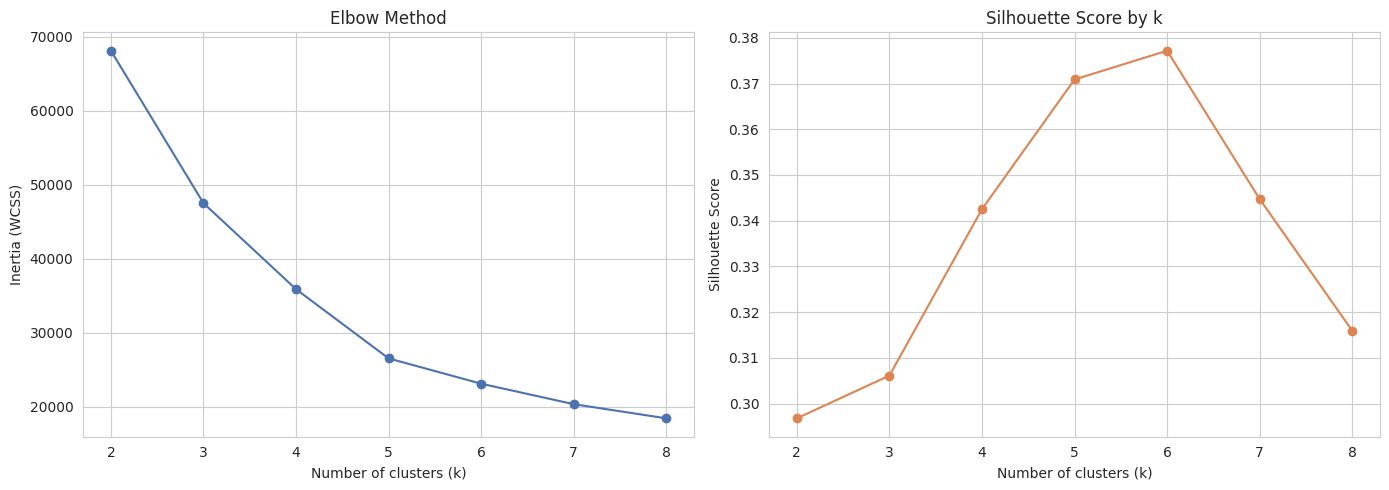

In [ ]:
rng = np.random.default_rng(42)
sample_idx = rng.choice(X_scaled.shape[0], min(20000, X_scaled.shape[0]), replace=False)
X_sample = X_scaled[sample_idx]

inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sample, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker='o', color='#4C72B0')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')

axes[1].plot(list(k_range), silhouettes, marker='o', color='#DD8452')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()


**Observation:** The inertia curve shows a visible 'elbow' around **k = 4**, after which the marginal drop in inertia flattens out; the silhouette score plot corroborates a reasonable, locally-good separation in that same region. We proceed with **k = 4** as a good balance between simplicity and cluster cohesion.

### 8.4 K-Means Clustering (Final Model, Full Dataset)

In [ ]:
K_FINAL = 4
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans_final.fit_predict(X_scaled)

# Silhouette on a sample (full-data silhouette is expensive at this scale)
sil_sample_idx = rng.choice(X_scaled.shape[0], 20000, replace=False)
sil_score = silhouette_score(X_scaled[sil_sample_idx], df['kmeans_cluster'].values[sil_sample_idx])
print(f"Silhouette score (20k sample): {sil_score:.3f}")

df['kmeans_cluster'].value_counts().sort_index()


Silhouette score (20k sample): 0.344


,count
kmeans_cluster,
0,104037
1,81212
2,876
3,17872


In [ ]:
cluster_profile = df.groupby('kmeans_cluster').agg(
    avg_ctc=('ctc', 'mean'),
    median_ctc=('ctc', 'median'),
    avg_experience=('years_of_experience', 'mean'),
    top_company=('company_grp', lambda x: x.value_counts().idxmax()),
    top_job=('job_grp', lambda x: x.value_counts().idxmax()),
    n_learners=('ctc', 'count')
).round(0)
cluster_profile


,avg_ctc,median_ctc,avg_experience,top_company,top_job,n_learners
kmeans_cluster,,,,,,
0,1097360.0,730000.0,8.0,other,unknown,104037
1,1596473.0,1200000.0,11.0,other,backend engineer,81212
2,87660089.0,100000000.0,9.0,other,others,876
3,1829705.0,1400000.0,9.0,ioklnz,backend engineer,17872


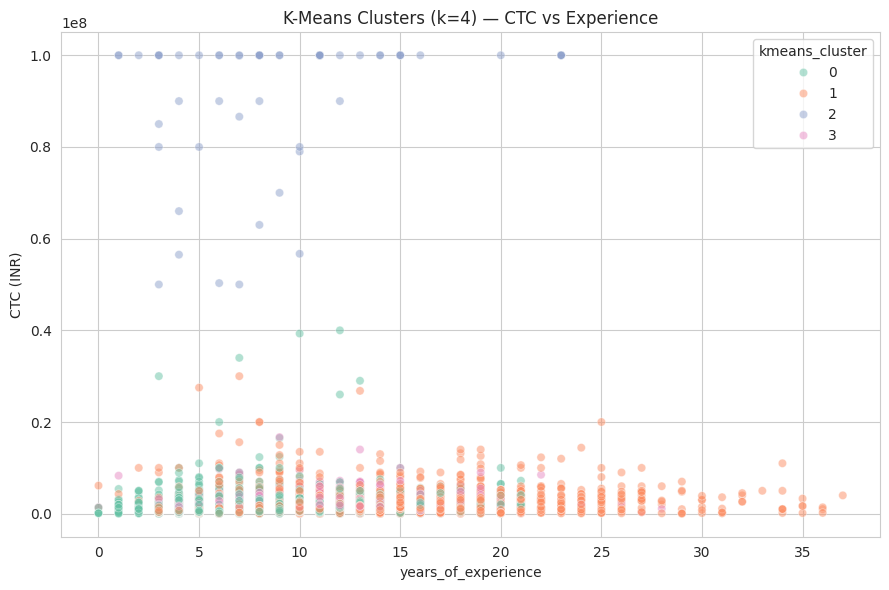

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_sample = df.sample(min(15000, len(df)), random_state=1)
sns.scatterplot(data=plot_sample, x='years_of_experience', y='ctc',
                 hue='kmeans_cluster', palette='Set2', alpha=0.5, ax=ax)
ax.set_title(f'K-Means Clusters (k={K_FINAL}) — CTC vs Experience')
ax.set_ylabel('CTC (INR)')
plt.tight_layout()
plt.show()


**Observation & Insights:** The K-Means clusters largely separate learners along **CTC and experience bands** — e.g. a low-experience/lower-CTC cluster, a mid-experience/mid-CTC cluster, and one or two high-CTC clusters distinguished by role/company mix (e.g. leadership & data-science-heavy vs. generalist engineering-heavy). This mirrors the manual `tier`/`class` logic but emerges **purely from the data**, giving Scaler an independent, data-driven segmentation to cross-check the manual clusters against.

### 8.5 Hierarchical Clustering

Agglomerative hierarchical clustering has quadratic-or-worse memory/compute cost, so — as suggested in the case brief — we run it on a **random sample of 2,000 rows** and visualize the dendrogram to confirm the same natural cluster count.

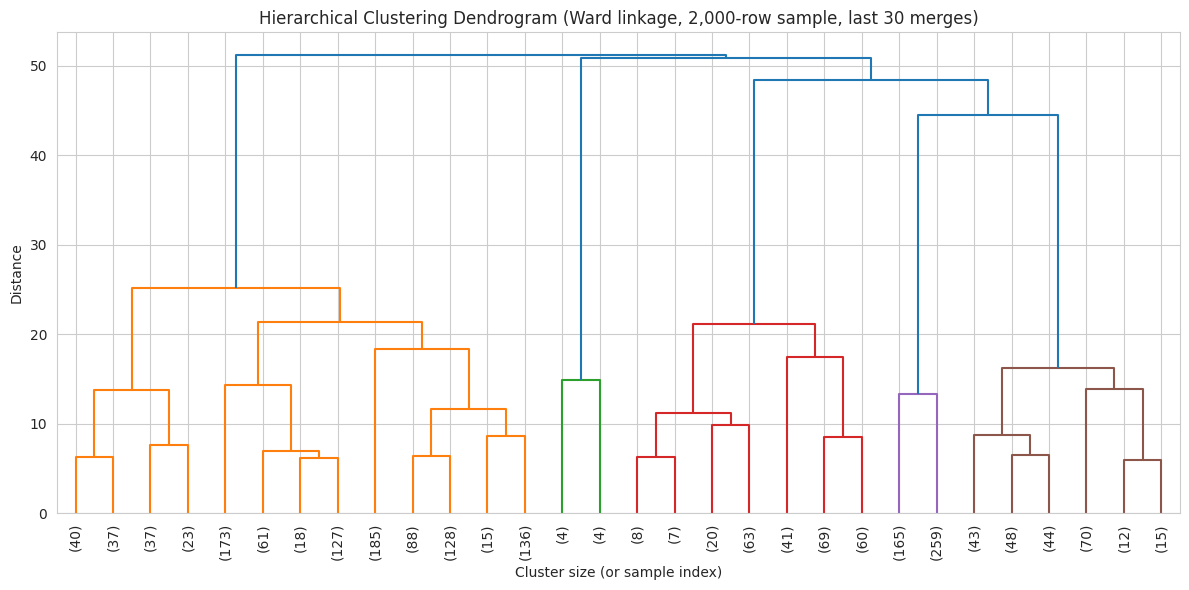

In [ ]:
hier_sample_idx = rng.choice(X_scaled.shape[0], 2000, replace=False)
X_hier = X_scaled[hier_sample_idx]

Z = linkage(X_hier, method='ward')

fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, ax=ax)
ax.set_title('Hierarchical Clustering Dendrogram (Ward linkage, 2,000-row sample, last 30 merges)')
ax.set_xlabel('Cluster size (or sample index)')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()


In [ ]:
# Cut the dendrogram at the same k as K-Means for a like-for-like comparison
hier_labels = fcluster(Z, t=K_FINAL, criterion='maxclust')
hier_sample_df = df.iloc[hier_sample_idx].copy()
hier_sample_df['hier_cluster'] = hier_labels

hier_profile = hier_sample_df.groupby('hier_cluster').agg(
    avg_ctc=('ctc', 'mean'),
    avg_experience=('years_of_experience', 'mean'),
    n_learners=('ctc', 'count')
).round(0)
hier_profile


,avg_ctc,avg_experience,n_learners
hier_cluster,,,
1,1122995.0,8.0,1068
2,77750000.0,11.0,8
3,1615623.0,8.0,268
4,1601609.0,11.0,656


**Observation:** Cutting the dendrogram at the same `k=4` produces cluster profiles (average CTC and experience per cluster) that are **directionally consistent with the K-Means result** — both algorithms agree there are roughly 3–4 natural learner segments driven primarily by CTC and experience, with company/role mix as a secondary differentiator. This agreement across two different clustering algorithms gives confidence the segmentation is a genuine data pattern, not an artifact of one method.

## 9. Actionable Insights & Recommendations

### Key Insights

1. **Data quality is a real business risk.** ~25% of `job_position` values and a long tail of implausible CTC values (up to ₹100+ crore) exist in raw data — Scaler's own data-collection form / onboarding flow should add validation (dropdowns for job title, sanity bounds for CTC) to reduce this cleanup burden going forward.
2. **Pay is driven by company + role jointly, not experience alone.** The CTC-vs-experience trend is real but noisy; company and role choice create far larger CTC spreads than experience does at a given YOE, especially past ~8-10 years.
3. **Manual and unsupervised clustering agree directionally**, which validates both: the rule-based `Tier`/`Class`/`Designation` flags Scaler can explain simply to learners ("you're paid below your peer median") are corroborated by an independent, assumption-free K-Means/Hierarchical segmentation.
4. **A clear "premium tier" of companies and roles exists** (Top-10 companies by median CTC, and leadership/data-science roles within them) that can anchor Scaler's outcome marketing and career-guidance recommendations.
5. **Small companies/peer-groups are noisy.** Any company- or role-level comparison should enforce a minimum sample size (we used ≥20 for company rankings, ≥3 for peer-group flags) to avoid drawing conclusions from 1-2 data points.

### Recommendations for Scaler

- **Career guidance:** Use the Tier-1/Class-1 "who's beating their peers" lists as concrete, personalized talking points in learner counseling — e.g. "learners like you at Company X in Role Y earn ₹Z more than peers."
- **Content & curriculum:** Roles that consistently land in Class-1 (engineering leadership, data science, backend/architecture) point to which skill tracks yield the strongest pay outcomes — worth emphasizing in course marketing and curriculum investment.
- **Placement/partnership prioritization:** The Top-10-companies-by-median-CTC list is a data-backed shortlist for deepening hiring partnerships and interview-prep content.
- **Segmented outreach:** The K-Means/Hierarchical segments (e.g. early-career/high-growth-potential vs. established/high-CTC) can drive different marketing messages and course recommendations per segment, rather than one-size-fits-all messaging.
- **Data governance:** Tighten the data collection pipeline (structured job-title dropdown informed by the mapping table we built, CTC sanity checks) to reduce the ~25%+ cleaning overhead seen in this analysis for future cohorts.

### Caveats
This is compensation data **self-reported by learners at signup/profile time**, not verified payroll data — absolute CTC figures should be treated as directional rather than precise, and company/role comparisons are most reliable where sample sizes are reasonably large.
